Rendering stigmergic-tracefinder GIF...
Displaying stigmergic-tracefinder...



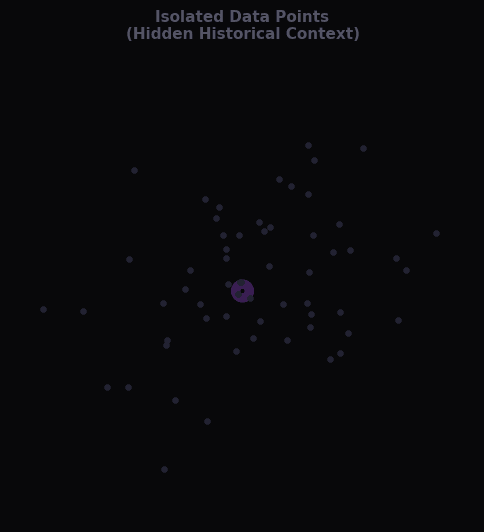

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io
import base64
from IPython.display import display, HTML
import warnings

# Suppress warnings for clean output
warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------
FRAMES = 100
FPS = 30
BG_COLOR = "#08080a"  # Deep void
COLOR_NODE_HIDDEN = "#222233"
COLOR_NODE_FOUND = "#ffaa00"  # Amber (Knowledge/History)
COLOR_TRACE = "#00ffcc"       # Cyan (The Stigmergic Link)
COLOR_PULSE = "#b055ff"       # Purple (The Scraping Pipeline)

# Set global Seaborn dark theme
sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": BG_COLOR,
    "figure.facecolor": BG_COLOR,
    "axes.edgecolor": "none",
    "grid.color": "none",
    "text.color": "#e0e0e0"
})

def fig_to_image(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', facecolor=fig.get_facecolor(), dpi=100)
    buf.seek(0)
    return Image.open(buf).copy()

# ---------------------------------------------------------
# Visualizer: stigmergic-tracefinder
# ---------------------------------------------------------
def generate_tracefinder_gif(filename):
    print("Rendering stigmergic-tracefinder GIF...")
    frames = []

    # Generate the hidden network of knowledge
    np.random.seed(42)
    n_nodes = 60

    # Create nodes clustered loosely around the center
    theta = np.random.uniform(0, 2*np.pi, n_nodes)
    r = np.random.normal(2.0, 1.5, n_nodes)
    x = r * np.cos(theta)
    y = r * np.sin(theta)

    # Pre-calculate distances to form the "hidden" edges (mycelium)
    edges = []
    for i in range(n_nodes):
        for j in range(i + 1, n_nodes):
            dist = np.sqrt((x[i] - x[j])**2 + (y[i] - y[j])**2)
            # Connect nodes if they are close enough (forming communities/disciplines)
            if dist < 1.5:
                # Store indices and distance for opacity scaling
                edges.append((i, j, dist))

    fig, ax = plt.subplots(figsize=(6, 6))

    for f in range(FRAMES):
        ax.clear()

        # p represents the expanding radial sweep of the scraper
        p = f / (FRAMES - 1)
        pulse_radius = p * 6.0  # Max radius to cover the grid

        # Draw the hidden network (nodes only, barely visible)
        ax.scatter(x, y, color=COLOR_NODE_HIDDEN, s=15, zorder=2)

        # The Scraping Pulse
        if p < 0.9:
            pulse = plt.Circle((0, 0), pulse_radius, color=COLOR_PULSE, fill=False, linewidth=2, alpha=1 - p)
            ax.add_patch(pulse)
            pulse_glow = plt.Circle((0, 0), pulse_radius - 0.1, color=COLOR_PULSE, fill=False, linewidth=10, alpha=(1 - p)*0.3)
            ax.add_patch(pulse_glow)

        # Draw the revealed network
        discovered_nodes = (x**2 + y**2) <= pulse_radius**2

        # Highlight discovered nodes
        ax.scatter(x[discovered_nodes], y[discovered_nodes], color=COLOR_NODE_FOUND, s=30, edgecolors="#ffffff", zorder=4)

        # Draw the stigmergic traces (edges) between discovered nodes
        for i, j, dist in edges:
            if discovered_nodes[i] and discovered_nodes[j]:
                # Calculate time since discovery to fade in the trace smoothly
                dist_i_from_center = np.sqrt(x[i]**2 + y[i]**2)
                dist_j_from_center = np.sqrt(x[j]**2 + y[j]**2)
                max_dist = max(dist_i_from_center, dist_j_from_center)

                # How far past the nodes the pulse has gone
                age = max(0, pulse_radius - max_dist)
                trace_alpha = min(0.6, age * 0.5) * (1 - dist/1.5) # Closer nodes have stronger traces

                # Draw the glowing connection
                ax.plot([x[i], x[j]], [y[i], y[j]], color=COLOR_TRACE, linewidth=1.5, alpha=trace_alpha, zorder=3)

        # Title dynamics
        if p < 0.3:
            title = "Isolated Data Points\n(Hidden Historical Context)"
            title_color = "#555566"
        elif p < 0.8:
            title = "Scraping Pipelines Active...\nTracing Conceptual Evolution"
            title_color = COLOR_PULSE
        else:
            title = "Stigmergic Network Revealed\n(Networks of Influence Mapped)"
            title_color = COLOR_TRACE

        ax.set_xlim(-5, 5)
        ax.set_ylim(-5, 5)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(title, color=title_color, pad=15, fontweight='bold', fontsize=11)

        frames.append(fig_to_image(fig))

    plt.close(fig)
    frames[0].save(filename, save_all=True, append_images=frames[1:], duration=int(1000/FPS), loop=0)
    return filename

# ---------------------------------------------------------
# Execution & Display
# ---------------------------------------------------------
file_tracefinder = generate_tracefinder_gif('stigmergic_tracefinder.gif')

def image_to_base64(filepath):
    with open(filepath, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

b64_tracefinder = image_to_base64(file_tracefinder)

print("Displaying stigmergic-tracefinder...")

html_code = f"""
<div style="display: flex; justify-content: center; font-family: 'Courier New', monospace; color: white;">

    <div style="text-align: center; max-width: 600px; padding: 20px; background-color: #08080a; border: 1px solid #222233; border-radius: 12px; box-shadow: 0 8px 30px rgba(176, 85, 255, 0.1);">
        <h2 style="color: #ffaa00; margin-bottom: 10px; font-size: 20px; letter-spacing: 1px;">stigmergic-tracefinder</h2>
        <p style="font-size: 12px; color: #888899; margin-bottom: 20px; line-height: 1.6;">
            A visual metaphor for unearthing the epistemology of concepts. Before the pipeline runs, authors and works appear as <b>isolated, disconnected nodes</b> in the dark. As the scraping pulse (Purple) washes over the latent space, it detects the environmental markers left by prior thoughts, permanently illuminating the <b>hidden mycelial network of influence</b> (Cyan) that spans across time and disciplines.
        </p>
        <img src="data:image/gif;base64,{b64_tracefinder}" style="border: 1px solid #111; border-radius: 8px; width: 100%;">
    </div>

</div>
"""

display(HTML(html_code))